# Aim
The purpose of this notebook is to show how to use JIT to tune a ParakeetCTC.

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd
%pip install nemo-toolkit[asr]>=2.6.1 matplotlib

In [ ]:
from time import perf_counter
from aitune.torch.jit.patcher import patch_for_jit_tuning
from aitune.torch.jit.patched_module import PatchedModule
from aitune.torch.jit.config import config
from notebooks.jit.jit_commons import visualize_latency
from copy import deepcopy
import nemo.collections.asr
import nemo.core.neural_types.neural_type
from nemo.core.classes.common import typecheck
import statistics
from nemo.collections.asr.parts.mixins.transcription import InternalTranscribeConfig, TranscribeConfig

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
TensorRT-LLM is not installed. Please install TensorRT-LLM or set TRTLLM_PLUGINS_PATH to the directory containing libnvinfer_plugin_tensorrt_llm.so to use converters for torch.distributed ops


[08/05/2025-15:19:28] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


15:19:29.780 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

[NeMo W 2025-08-05 15:19:30 nemo_logging:405] /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
      warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
    
15:19:30.566 - INFO - PyTorch version 2.7.1 available.


In [3]:
sample_file_path = "notebooks/jit/2086-149220-0033.wav"
max_bs = 64

# ParakeetCTC

In [ ]:
config.dry_run = False
config.min_samples = 4
config.max_depth_level = 3
config.detect_graph_breaks = True
config.dry_run_failure_probability = 0.8

In [ ]:
def get_bare_model(model_name: str = "nvidia/parakeet-ctc-0.6b"):
    # Note: Disable typechecking for nemo, as passing inputs between onnx and nemo fails
    typecheck.set_typecheck_enabled(False)
    asr_model = nemo.collections.asr.models.EncDecCTCModel.from_pretrained(model_name=model_name)
    cfg = deepcopy(asr_model.decoding.cfg)
    cfg.strategy = "greedy_batch"
    asr_model.change_decoding_strategy(cfg)
    asr_model.eval()
    asr_model = asr_model.to("cuda")
    # Note: Move STFT window to GPU
    asr_model.preprocessor.featurizer.window = asr_model.preprocessor.featurizer.window.to("cuda")
    return asr_model


@patch_for_jit_tuning
def get_parakeet_ctc(model_name: str = "nvidia/parakeet-ctc-0.6b"):
    return get_bare_model(model_name)

In [6]:
pipeline = get_parakeet_ctc()

[NeMo I 2025-08-05 15:19:31 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2025-08-05 15:19:32 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /disk1/NVIDIA/datasets/LibriSpeech_NeMo/librivox-train-all.json
    sample_rate: 16000
    batch_size: 16
    shuffle: true
    num_workers: 8
    pin_memory: true
    use_start_end_token: false
    trim_silence: false
    max_duration: 16.7
    min_duration: 0.1
    is_tarred: false
    tarred_audio_filepaths: null
    shuffle_n: 2048
    bucketing_strategy: fully_randomized
    bucketing_batch_size: null
    
[NeMo W 2025-08-05 15:19:32 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: /disk1/NVIDIA/datasets

[NeMo I 2025-08-05 15:19:32 nemo_logging:393] PADDING: 0
[NeMo I 2025-08-05 15:19:35 nemo_logging:393] Model EncDecCTCModelBPE was successfully restored from /home/pbazan/.cache/huggingface/hub/models--nvidia--parakeet-ctc-0.6b/snapshots/16ca39445465932bfbaeb5126933d5ce8bd43a77/parakeet-ctc-0.6b.nemo.
[NeMo I 2025-08-05 15:19:35 nemo_logging:393] Changed decoding strategy to 
    strategy: greedy_batch
    preserve_alignments: null
    compute_timestamps: null
    word_seperator: ' '
    segment_seperators:
    - .
    - '!'
    - '?'
    segment_gap_threshold: null
    ctc_timestamp_type: all
    batch_dim_index: 0
    greedy:
      preserve_alignments: false
      compute_timestamps: false
      preserve_frame_confidence: false
      confidence_method_cfg: null
      ngram_lm_model: null
      ngram_lm_alpha: 0.0
      allow_cuda_graphs: true
    beam:
      beam_size: 4
      search_type: default
      preserve_alignments: false
      compute_timestamps: false
      return_best_hypo

In [7]:
def call_wrapper(*args, **kwargs):
    # Note: tunning is controlling batch size and it needs to be passed down to the transcribe function because by default it is 4
    batch_size = len(kwargs["audio"])
    return pipeline.transcribe(
        *args,
        **kwargs,
        override_config=TranscribeConfig(_internal=InternalTranscribeConfig(device="cuda"), batch_size=batch_size),
        verbose=False,
        batch_size=batch_size,
    )


Transcribing:   0%|          | 0/1 [00:00<?, ?it/s]

Transcribing:   0%|          | 0/1 [00:00<?, ?it/s]15:19:39.443 - INFO - ------------------------------------------------------------
15:19:39.443 - INFO - 🚀 Tuning graph `0` for module `ConvASRDecoder 📊1.1M`:
15:19:39.443 - INFO -   number of parameters: 1.1M
15:19:39.444 - INFO -   number of layers: 1
15:19:39.444 - INFO -   precisions: torch.float32
15:19:39.444 - INFO -   graph_spec:
15:19:39.444 - INFO -     input_spec: ((), {encoder_output: input__0[dim0, 1024, 93] min_shape=[1, 1024, 93] max_shape=[64, 1024, 93] dtype=torch.float32})
15:19:39.444 - INFO -     output_spec: output__0[dim0, 93, 1025] min_shape=[1, 93, 1025] max_shape=[64, 93, 1025] dtype=torch.float32
15:19:39.445 - INFO -   num samples: 1
15:19:39.445 - INFO -   device: cuda
15:19:39.445 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/fa55bc9b9904f01057b4b6eb875ef1d14be27022427909b2a26b87ed71f74a29/0
15:19:39.445 - INFO -   strategy:
15:19:39.446 - INFO -     name: JIT Strategy
15:19:39.446 - INFO -     descr

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored


15:19:46.733 - Level 28 - [I] Finished engine building in 5.489 seconds
15:19:46.737 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/fa55bc9b9904f01057b4b6eb875ef1d14be27022427909b2a26b87ed71f74a29/0/TensorRTBackend/af74c28a036db3019c5a3923d6c2511e1d3083af4ef6c8f99fea2628d19ad0f2/model.plan
15:19:46.942 - INFO -     ✅ backend built
15:19:46.944 - INFO -     ✅ backend validated
15:19:46.945 - INFO - 🎯 Strategy JitStrategy execution finished in 7.50s.
15:19:46.945 - INFO - ✅ Selected backend: TensorRTBackend(precision=fp16)


[08/05/2025-15:19:46] [TRT] [I] Loaded engine size: 2 MiB
[08/05/2025-15:19:46] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +23, now: CPU 0, GPU 25 (MiB)


...

15:21:09.945 - INFO -     ❌ backend failed due to inf/nan values. Retrying with fp32 precision
15:21:09.945 - INFO - ⚙️ backend:  TensorRTBackend(precision=fp32)
15:21:09.946 - INFO -     🔄 in progress...please wait
15:21:20.894 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(1, 80, 744), opt=(64, 80, 744), max=(64, 80, 744)],
             input__1 [min=(1,), opt=(64,), max=(64,)]}
    ]
15:21:20.900 - Level 22 - [I] Building engine with configuration:
    Flags                  | [TF32]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 48632.00 MiB, TACTIC_DRAM: 48632.00 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
15:21:51.174 - Level 28 - [I] Finished engine building in 30.274 seconds
15:21:52.132 - INFO - [I] Saving engine t

[08/05/2025-15:21:54] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/05/2025-15:21:54] [TRT] [I] Loaded engine size: 2370 MiB
[08/05/2025-15:21:54] [TRT] [I] [MS] Running engine with multi stream info
[08/05/2025-15:21:54] [TRT] [I] [MS] Number of aux streams is 2
[08/05/2025-15:21:54] [TRT] [I] [MS] Number of total worker streams is 3
[08/05/2025-15:21:54] [TRT] [I] [MS] The main stream provided by execute/enqueue calls is the first worker stream


15:21:54.542 - INFO -     ✅ backend built
15:21:54.565 - INFO -     ✅ backend validated
15:21:54.565 - INFO - 🎯 Strategy JitStrategy execution finished in 2m 4s.
15:21:54.565 - INFO - ✅ Selected backend: TensorRTBackend(precision=fp32)
Transcribing: 100%|██████████| 1/1 [02:16<00:00, 136.90s/it]


[08/05/2025-15:21:54] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +1244, now: CPU 0, GPU 3588 (MiB)


Transcribing: 100%|██████████| 1/1 [00:03<00:00,  3.88s/it]


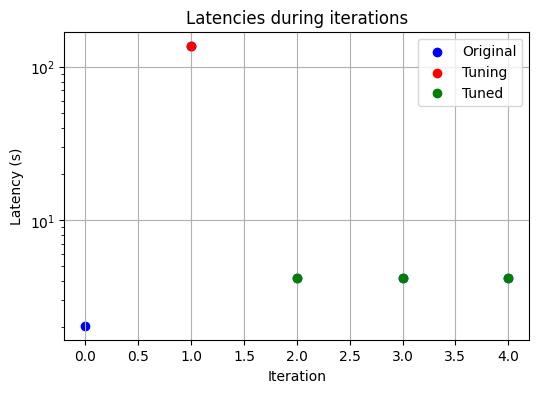

In [ ]:
def batch():    
    call_wrapper(audio=[sample_file_path] * 1)
    call_wrapper(audio=[sample_file_path] * max_bs)

visualize_latency(lambda: batch(), iterations=5)

In [9]:
PatchedModule.history

['New top module: EncDecCTCModelBPE 📊608.8M level=0🪜 state=init⏳ call_count=1',
 'New child module: ConformerEncoder 📊607.7M level=1🪜 state=init⏳ call_count=1',
 'New child module: ConvSubsampling 📊2.8M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: ConformerLayer 📊25.2M level=2🪜 state=in

In [10]:
PatchedModule.print_hierarchy()

PatchedModule Hierarchy:
├─ EncDecCTCModelBPE 📊608.8M level=0🪜 state=eager⚠️ (graph break) call_count=4
  ├─ ConformerEncoder 📊607.7M level=1🪜 state=tuned🎯 (TensorRTBackend) call_count=4
    ├─ ConvSubsampling 📊2.8M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count=4
    ├─ ConformerLayer 📊25.2M level=2🪜 state=detached☑️ call_count

# Benchmark

The following benchmark has to be taken with a grain of salt. Seems the bare model is susceptible to high speed variance.

In [15]:
def benchmark(model, test_files, num_runs=10):
    """Simple timing benchmark."""
    print(f"🔥 Running {num_runs} iterations...")

    def infer(*args, **kwargs):
        return model.transcribe(
            *args,
            **kwargs,
            override_config=TranscribeConfig(_internal=InternalTranscribeConfig(device="cuda")),
            verbose=False,
        )

    # Warmup
    for _ in range(3):
        infer(**test_files)

    # Time it
    times = []
    for i in range(num_runs):
        start = perf_counter()
        infer(**test_files)
        end = perf_counter()
        times.append(end - start)
        print(f"   Run {i + 1}: {times[-1]:.3f}s")

    avg_time = statistics.mean(times)
    throughput = len(test_files["audio"]) / avg_time

    print(f"   📊 Average: {avg_time:.3f}s ({throughput:.1f} files/sec)")
    return avg_time, throughput

In [16]:
test_files = {"audio": [sample_file_path] * max_bs}
acc_time, acc_throughput = benchmark(pipeline, test_files)

🔥 Running 10 iterations...


Transcribing:   0%|          | 0/16 [00:00<?, ?it/s]

Transcribing: 100%|██████████| 16/16 [00:00<00:00, 18.30it/s]


   Run 1: 0.886s


Transcribing: 100%|██████████| 16/16 [00:00<00:00, 18.30it/s]


...

   Run 8: 0.895s


Transcribing: 100%|██████████| 16/16 [00:00<00:00, 18.24it/s]


   Run 9: 0.890s


Transcribing: 100%|██████████| 16/16 [00:00<00:00, 18.19it/s]

   Run 10: 0.894s
   📊 Average: 0.894s (71.6 files/sec)


In [17]:
pipeline = get_bare_model()
orig_time, orig_throughput = benchmark(pipeline, test_files)

[NeMo I 2025-08-05 15:40:50 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2025-08-05 15:40:50 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /disk1/NVIDIA/datasets/LibriSpeech_NeMo/librivox-train-all.json
    sample_rate: 16000
    batch_size: 16
    shuffle: true
    num_workers: 8
    pin_memory: true
    use_start_end_token: false
    trim_silence: false
    max_duration: 16.7
    min_duration: 0.1
    is_tarred: false
    tarred_audio_filepaths: null
    shuffle_n: 2048
    bucketing_strategy: fully_randomized
    bucketing_batch_size: null
    
[NeMo W 2025-08-05 15:40:50 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: /disk1/NVIDIA/datasets

[NeMo I 2025-08-05 15:40:50 nemo_logging:393] PADDING: 0
[NeMo I 2025-08-05 15:40:53 nemo_logging:393] Model EncDecCTCModelBPE was successfully restored from /home/pbazan/.cache/huggingface/hub/models--nvidia--parakeet-ctc-0.6b/snapshots/16ca39445465932bfbaeb5126933d5ce8bd43a77/parakeet-ctc-0.6b.nemo.
[NeMo I 2025-08-05 15:40:53 nemo_logging:393] Changed decoding strategy to 
    strategy: greedy_batch
    preserve_alignments: null
    compute_timestamps: null
    word_seperator: ' '
    segment_seperators:
    - .
    - '!'
    - '?'
    segment_gap_threshold: null
    ctc_timestamp_type: all
    batch_dim_index: 0
    greedy:
      preserve_alignments: false
      compute_timestamps: false
      preserve_frame_confidence: false
      confidence_method_cfg: null
      ngram_lm_model: null
      ngram_lm_alpha: 0.0
      allow_cuda_graphs: true
    beam:
      beam_size: 4
      search_type: default
      preserve_alignments: false
      compute_timestamps: false
      return_best_hypo

Transcribing: 100%|██████████| 16/16 [00:01<00:00, 15.06it/s]


   Run 1: 1.073s


...

   Run 8: 1.061s


Transcribing: 100%|██████████| 16/16 [00:01<00:00, 15.24it/s]


   Run 9: 1.061s


Transcribing: 100%|██████████| 16/16 [00:01<00:00, 15.33it/s]

   Run 10: 1.053s
   📊 Average: 1.060s (60.4 files/sec)


In [18]:
speedup = orig_time / acc_time
improvement = ((acc_throughput - orig_throughput) / orig_throughput) * 100

In [19]:

print("\n" + "=" * 60)
print("🏁 FINAL RESULTS")
print("=" * 60)
print(f"🔧 Original:    {orig_time:.3f}s ({orig_throughput:.1f} files/sec)")
print(f"⚡ Accelerated: {acc_time:.3f}s ({acc_throughput:.1f} files/sec)")
print(f"🚀 Speedup:     {speedup:.2f}x ({improvement:+.1f}%)")



🏁 FINAL RESULTS
🔧 Original:    1.060s (60.4 files/sec)
⚡ Accelerated: 0.894s (71.6 files/sec)
🚀 Speedup:     1.19x (+18.6%)
